## Import Libraries

In [151]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset

In [152]:
df = pd.read_csv("clean_data.csv")

df.head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
0,1.924176,-0.284236,1.960029,0.959861,-0.446817,-0.364023,0.327518,0.100738,1.074541,-0.410937,2.0,0.0,0.0
1,-0.163476,0.337306,-0.510197,-0.696033,-0.446817,-0.364023,-1.468996,-2.183030,-0.470316,-1.501272,21.0,2.0,0.0
2,-0.645242,0.958849,-0.510197,-0.696033,-0.446817,-0.364023,0.327518,-1.663473,0.642191,-0.410937,13.0,5.0,0.0
3,-0.886125,0.958849,-0.510197,0.959861,-0.446817,-0.364023,0.327518,-0.344596,-0.106511,-0.592660,23.0,2.0,0.0
4,0.719761,1.580391,-0.510197,-0.696033,-0.446817,-0.364023,0.327518,-1.246685,2.039417,-0.229215,11.0,5.0,0.0


## Feature & Target

In [153]:
X = df.drop([
    'spam_label',
    'num_special_chars',
    'messages_sent_last_24h',
    'spam_keyword_score',
    'legit_keyword_score'
], axis=1)

y = df['spam_label']

## Train Test Split

In [154]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [155]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Apply Smote

In [156]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(pd.Series(y_train_smote).value_counts())

spam_label
1.0    3382
0.0    3382
Name: count, dtype: int64


## Naive Bayes Classifier

In [157]:
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

## Accuracy & Classification Report

In [158]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test,y_pred))

Accuracy: 0.9278846153846154

Classification Report:

              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96       845
         1.0       0.81      0.81      0.81       195

    accuracy                           0.93      1040
   macro avg       0.88      0.88      0.88      1040
weighted avg       0.93      0.93      0.93      1040



## Confusion Matrix

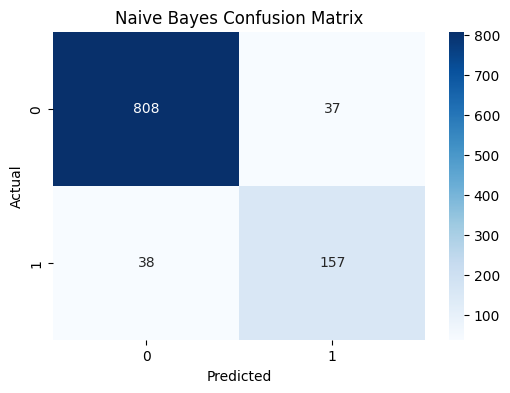

In [159]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Compute Conditional Probability

In [160]:
spam = df[df["spam_label"] == 1]

high_keyword = spam["spam_keyword_score"] > 5

prob = high_keyword.mean()

print("P(High Spam Keyword | Spam) =", round(prob,3))

P(High Spam Keyword | Spam) = 0.0


## Demonstrate Bayes' Theorem

In [161]:
P_spam = (df["spam_label"] == 1).mean()

P_keyword = (df["spam_keyword_score"] > 5).mean()

P_keyword_given_spam = (
    (df["spam_keyword_score"] > 5) &
    (df["spam_label"] == 1)
).sum() / (df["spam_label"] == 1).sum()

P_spam_given_keyword = (
    P_keyword_given_spam * P_spam
) / P_keyword

print("P(Spam | High Keyword) =", round(P_spam_given_keyword,3))

P(Spam | High Keyword) = nan


C:\Users\Shyamdev verma\AppData\Local\Temp\ipykernel_8216\4040783050.py:10: RuntimeWarning: invalid value encountered in scalar divide
  P_spam_given_keyword = (


In [171]:
sample = X_test.iloc[[0]]
sample

,message_length,word_count,num_urls,num_digits,sender_activity_score,sender_account_age_days,hour_of_day,day_of_week
799,0.719761,1.580391,-0.510197,-0.696033,-1.543575,-0.074875,20.0,2.0


In [163]:
prediction = nb.predict(sample)

print("Model Prediction :", prediction[0])

Model Prediction : 0.0


In [164]:
print(nb.predict_proba(sample))

[[9.99873754e-01 1.26245895e-04]]


## Conclusion

The Gaussian Naive Bayes classifier was implemented to classify messages as spam or legitimate.

 Conditional probabilities were manually calculated using the spam_keyword_score feature, and Bayes' Theorem was applied to estimate the probability of a message being spam. 
 
 The manually computed probabilities were then compared with the probabilities returned by the Naive Bayes model (predict_proba()), showing how theoretical probability aligns with the model's predictions.